In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, NotRequired
from dotenv import load_dotenv

/Users/vikrmaditya/Downloads/Code/LangGraph/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

model = ChatGroq(
    model= 'llama-3.1-8b-instant',
    temperature= 0.5
)

In [3]:
# define state
class BlogState(TypedDict):

    title: str
    outline: NotRequired[str]
    content: NotRequired[str]
    rating: NotRequired[str]

In [4]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # llm generation
    prompt = f'Generate a detailed outline for a blog from the given topic: {title}, without any bold or any type of text decoration'
    outline = model.invoke(prompt).content

    # state updation
    state['outline'] = outline
    return state


In [5]:
def create_blog(state: BlogState) -> BlogState:

    # fetch title & outline
    title = state['title']
    outline = state['outline']

    # LLM generation
    prompt = f'Write a detailed Blog on the  {title} using the following:\n{outline}, without any bold or any type of text decoration'
    content = model.invoke(prompt).content

    # state updation
    state['content'] = content
    return state

In [ ]:
def evaluate_blog(state: BlogState) -> BlogState:

    # fetch title & outline
    title = state['title']
    outline = state['outline']
    content = state['content']

    # LLM generation
    prompt = f"Based on topic:{title}, and its outline{outline}, rate my blog \n\n{content},\n\n out of 10"
    rating = model.invoke(prompt).content

    # state updation
    state['rating'] = rating
    return state

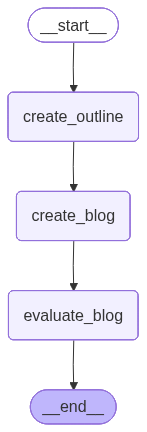

In [7]:
# define graph
graph = StateGraph(BlogState)

# define nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('evaluate_blog', evaluate_blog)

# define edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'evaluate_blog')
graph.add_edge('evaluate_blog', END)

# workflow
workflow = graph.compile()
workflow

In [8]:
initial_state = {'title':'Rise of AI after attention is all you need paper'}

final_state = workflow.invoke(initial_state)

In [9]:
print(final_state)

{'title': 'Rise of AI after attention is all you need paper', 'outline': 'I. Introduction\n  A. Brief overview of the paper "Attention is All You Need"\n  B. Background on the Transformer model and its impact on NLP\n  C. Importance of the paper in the rise of AI\n\nII. The Transformer Model and Attention Mechanism\n  A. Introduction to the Transformer model and its architecture\n  B. Explanation of the attention mechanism and its role in the model\n  C. Comparison with traditional recurrent neural networks (RNNs)\n\nIII. Key Contributions of the Paper\n  A. Introduction to the paper\'s main contributions\n  B. Explanation of the self-attention mechanism and its benefits\n  C. Discussion of the paper\'s impact on the field of NLP\n\nIV. Rise of AI after the Attention is All You Need Paper\n  A. Overview of the paper\'s influence on AI research and development\n  B. Discussion of the paper\'s impact on various AI applications\n  C. Examples of successful AI models and applications that 

In [10]:
print(final_state['rating'])

I would rate this comprehensive overview of the "Attention is All You Need" paper and its impact on the rise of AI as 9 out of 10. Here's a breakdown of the strengths and weaknesses:

Strengths:

1. **Clear and concise structure**: The blog post is well-organized, with a logical flow of ideas and a clear introduction to the topic.
2. **Comprehensive coverage**: The post covers the key aspects of the Transformer model, its attention mechanism, and the paper's impact on AI research and development.
3. **Useful examples and applications**: The post provides concrete examples of successful AI models and applications that built upon the Transformer model, making it easier for readers to understand the practical implications of the research.
4. **Good balance of technical and non-technical content**: The post strikes a good balance between technical details and non-technical explanations, making it accessible to readers with varying levels of technical expertise.
5. **Up-to-date references**

In [11]:
print(f"Outline:\n{final_state['outline']}\n\nContent:\n{final_state['content']}")

Outline:
I. Introduction
  A. Brief overview of the paper "Attention is All You Need"
  B. Background on the Transformer model and its impact on NLP
  C. Importance of the paper in the rise of AI

II. The Transformer Model and Attention Mechanism
  A. Introduction to the Transformer model and its architecture
  B. Explanation of the attention mechanism and its role in the model
  C. Comparison with traditional recurrent neural networks (RNNs)

III. Key Contributions of the Paper
  A. Introduction to the paper's main contributions
  B. Explanation of the self-attention mechanism and its benefits
  C. Discussion of the paper's impact on the field of NLP

IV. Rise of AI after the Attention is All You Need Paper
  A. Overview of the paper's influence on AI research and development
  B. Discussion of the paper's impact on various AI applications
  C. Examples of successful AI models and applications that built upon the Transformer model

V. Applications of the Transformer Model
  A. Overvie

In [12]:
print(f"Content \n\n\n{final_state['content']}")

Content 


**The Rise of AI after "Attention is All You Need": A Comprehensive Overview**

**Introduction**

In 2017, Vaswani et al. published a groundbreaking paper titled "Attention is All You Need," which introduced the Transformer model, a revolutionary architecture for natural language processing (NLP) tasks. This paper marked a significant shift in the field of NLP, paving the way for the development of more efficient and effective AI models. In this blog post, we will delve into the Transformer model, its attention mechanism, and the paper's key contributions. We will also explore the rise of AI after the "Attention is All You Need" paper, its applications, challenges, and limitations.

**II. The Transformer Model and Attention Mechanism**

**A. Introduction to the Transformer model and its architecture**

The Transformer model is a neural network architecture designed specifically for NLP tasks. It consists of an encoder and a decoder, both of which are composed of multiple ide